# Motif detection example (Fig. 1)


In [6]:
import random
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from src.external.Oblique_Classifier_1 import ObliqueClassifier1


def generate_dna_sequence(length: int) -> str:
    return ''.join(random.choice('ATCG') for _ in range(length))


def insert_motif(sequence: str, motif: str, force_insertion: bool = False):
    if not motif:
        return sequence, False

    motif_len = len(motif)
    seq_len = len(sequence)

    if motif_len > seq_len:
        if force_insertion:
            return motif + sequence[motif_len:], True
        return sequence, False

    possible_start_positions = seq_len - motif_len + 1
    if possible_start_positions <= 0:
        if force_insertion:
            return motif + sequence[motif_len:], True
        return sequence, False

    start_index = random.randint(0, possible_start_positions - 1)
    end_index = start_index + motif_len
    new_sequence = list(sequence)
    new_sequence[start_index:end_index] = list(motif)
    return ''.join(new_sequence), True


def generate_dataset(num_samples: int, seq_length: int, motif_str: str, seed: Optional[int] = None):
    if seed is not None:
        random.seed(seed)

    sequences = []
    labels = []
    num_positive = num_samples // 2
    num_negative = num_samples - num_positive

    generated_positive = 0
    while generated_positive < num_positive:
        base_seq = generate_dna_sequence(seq_length)
        seq_with_motif, inserted = insert_motif(base_seq, motif_str, force_insertion=True)
        if inserted:
            sequences.append(seq_with_motif)
            labels.append(1)
            generated_positive += 1

    generated_negative = 0
    while generated_negative < num_negative:
        seq = generate_dna_sequence(seq_length)
        if motif_str not in seq:
            sequences.append(seq)
            labels.append(0)
            generated_negative += 1

    # Shuffle before splitting into train/test.
    combined = list(zip(sequences, labels))
    random.shuffle(combined)
    sequences, labels = zip(*combined)
    return list(sequences), np.array(labels)


def one_hot_encode_dna(sequences):
    mapping = {
        'A': [1, 0, 0, 0],
        'T': [0, 1, 0, 0],
        'C': [0, 0, 1, 0],
        'G': [0, 0, 0, 1],
        'N': [0, 0, 0, 0],
    }
    encoded_sequences = []
    for seq in sequences:
        one_hot_seq = [mapping.get(nucleotide, [0, 0, 0, 0]) for nucleotide in seq]
        encoded_sequences.append(np.array(one_hot_seq).flatten())
    return np.array(encoded_sequences)


def build_model(method: str, depth: int, seed: int):
    if method == 'CART':
        return DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=1,
            random_state=seed,
        )
    if method == 'OC1':
        return ObliqueClassifier1(
            criterion='gini',
            max_depth=depth,
            min_samples_leaf=1,
            random_state=seed,
            num_tries=40,
        )
    raise ValueError(f'Unknown method: {method}')


NUM_SAMPLES = 2000
SEQ_LENGTH = 100
MOTIF = 'TATA'
MAX_DEPTHS_LIST = list(range(1, 15))
TEST_SIZE = 0.3
NUM_SEEDS = 5
BASE_RANDOM_STATE = 42
METHODS = ['CART', 'OC1']


In [7]:
from pathlib import Path

ARTIFACT_DIR = Path('../artifacts/motif_example')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_ARTIFACT = ARTIFACT_DIR / (
    f'results_df_samples{NUM_SAMPLES}_len{SEQ_LENGTH}_motif{MOTIF}_'
    f'seeds{BASE_RANDOM_STATE}-{BASE_RANDOM_STATE + NUM_SEEDS - 1}_'
    f'depths{min(MAX_DEPTHS_LIST)}-{max(MAX_DEPTHS_LIST)}.csv'
)

FORCE_RERUN_BASELINES = False


def run_single_seed(seed: int):
    # Generate and split once per seed so every method sees identical data.
    raw_sequences, labels = generate_dataset(NUM_SAMPLES, SEQ_LENGTH, MOTIF, seed=seed)
    X = one_hot_encode_dna(raw_sequences)
    y = labels

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=seed,
        stratify=y,
    )

    seed_results = []
    for method in METHODS:
        for depth in MAX_DEPTHS_LIST:
            print(f'  Method: {method}, Depth: {depth}')
            model = build_model(method, depth, seed)
            model.fit(X_train, y_train)

            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)

            seed_results.append(
                {
                    'Seed': seed,
                    'Method': method,
                    'Depth': depth,
                    'Set': 'Train',
                    'Accuracy': accuracy_score(y_train, y_train_pred),
                }
            )
            seed_results.append(
                {
                    'Seed': seed,
                    'Method': method,
                    'Depth': depth,
                    'Set': 'Test',
                    'Accuracy': accuracy_score(y_test, y_test_pred),
                }
            )
            print(f'    Train Accuracy: {seed_results[-2]["Accuracy"]:.4f}, Test Accuracy: {seed_results[-1]["Accuracy"]:.4f}')

    return seed_results


if RESULTS_ARTIFACT.exists() and not FORCE_RERUN_BASELINES:
    print(f'Loading cached results from {RESULTS_ARTIFACT}')
    results_df = pd.read_csv(RESULTS_ARTIFACT)
else:
    print('Running baselines (CART + OC1) ...')
    all_results = []
    for seed in range(BASE_RANDOM_STATE, BASE_RANDOM_STATE + NUM_SEEDS):
        print(f'Running seed {seed}...')
        all_results.extend(run_single_seed(seed))

    results_df = pd.DataFrame(all_results)
    results_df.to_csv(RESULTS_ARTIFACT, index=False)
    print(f'Saved results artifact to {RESULTS_ARTIFACT}')

results_df.head()



Loading cached results from ../artifacts/motif_example/results_df_samples2000_len100_motifTATA_seeds42-46_depths1-14.csv


,Seed,Method,Depth,Set,Accuracy
0,42,CART,1,Train,0.545000
1,42,CART,1,Test,0.475000
2,42,CART,2,Train,0.579286
3,42,CART,2,Test,0.490000
4,42,CART,3,Train,0.597857


/tmp/ipykernel_915499/330776109.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


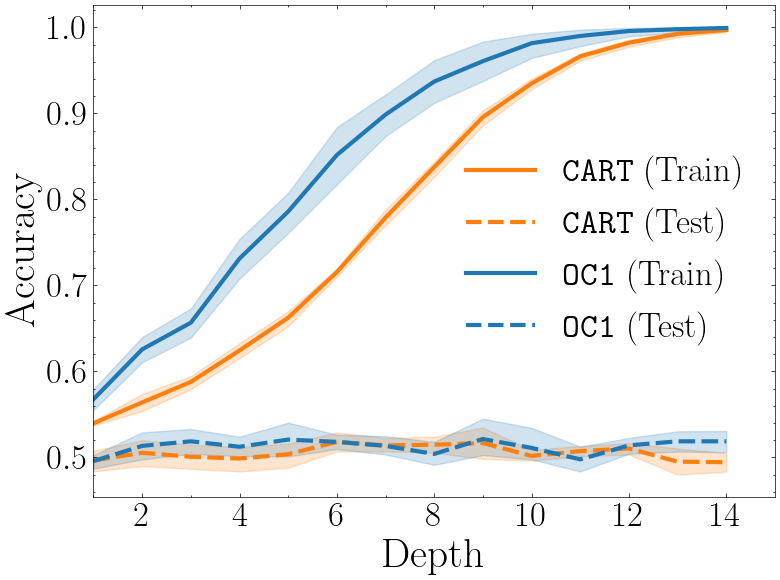

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science'])

# Match adaptive_trees plotting style setup
plt.rcParams['axes.labelsize'] = 30
plt.rcParams['axes.titlesize'] = 25
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.rcParams['legend.fontsize'] = 25
legend_title_fontsize = plt.rcParams['legend.fontsize'] * 0.95
legend_item_fontsize = plt.rcParams['legend.fontsize'] * 0.9

figsize = (8, 6)
plt.figure(figsize=figsize)

df_results_total = results_df.copy()
df_results_total['Method'] = df_results_total['Method'].replace(
    {'CART': r'$\texttt{CART}$', 'OC1': r'$\texttt{OC1}$'}
)

method_order = [r'$\texttt{CART}$', r'$\texttt{OC1}$']
set_order = ['Train', 'Test']

colors = {
    r'$\texttt{CART}$': '#ff7f0e',
    r'$\texttt{OC1}$': '#1f77b4',
}

sns.lineplot(
    data=df_results_total,
    x='Depth',
    y='Accuracy',
    hue='Method',
    style='Set',
    hue_order=method_order,
    style_order=set_order,
    markers=False,
    linewidth=3,
    ci=95,
    palette=colors,
)

major_ticks = np.arange(2, 15, 2)
minor_ticks = np.arange(1, 10, 2)

plt.gca().set_xticks(major_ticks)
plt.gca().set_xticks(minor_ticks, minor=True)

plt.xlabel('Depth')
plt.ylabel('Accuracy')
plt.xlim(1, 15)

custom_lines = []
custom_labels = []

for method in method_order:
    train_line = plt.Line2D([0], [0], color=colors[method], linestyle='-', linewidth=3)
    custom_lines.append(train_line)
    custom_labels.append(f'{method} (Train)')

    test_line = plt.Line2D([0], [0], color=colors[method], linestyle='--', linewidth=3)
    custom_lines.append(test_line)
    custom_labels.append(f'{method} (Test)')

plt.legend(custom_lines, custom_labels, loc='best')
plt.tight_layout()
plt.savefig('../figures/motif_detection_example.pdf', dpi=300)

fig = plt.gcf()
ax = plt.gca()

